In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('24-medical_cost.csv')

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   str    
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   str    
 6   region    1338 non-null   str    
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB


In [5]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


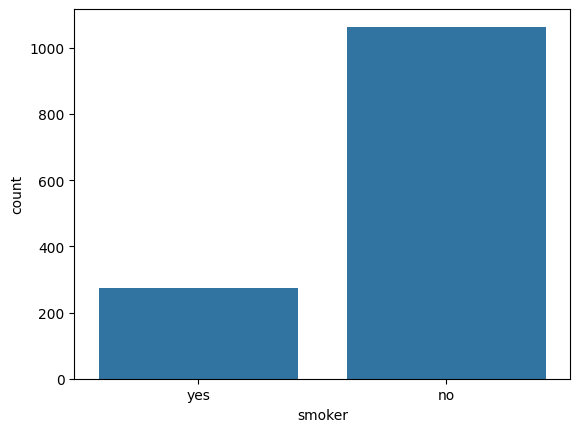

In [7]:
sns.countplot(data = df,x = 'smoker')
plt.show()

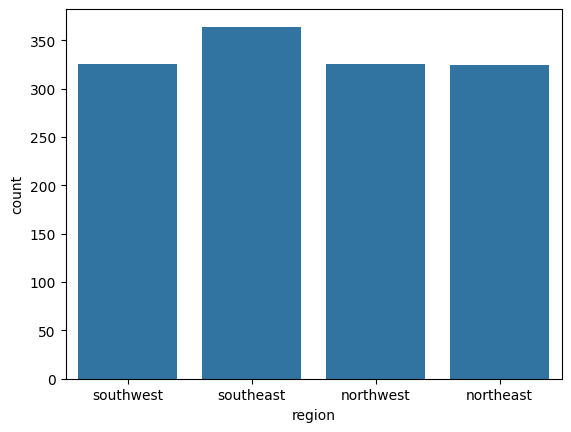

In [8]:
sns.countplot(data = df,x = 'region')
plt.show()

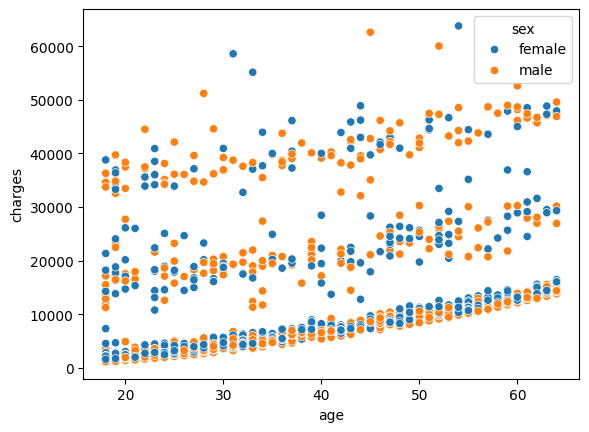

In [10]:
sns.scatterplot(data = df,x = 'age', y='charges',hue = 'sex')
plt.show()

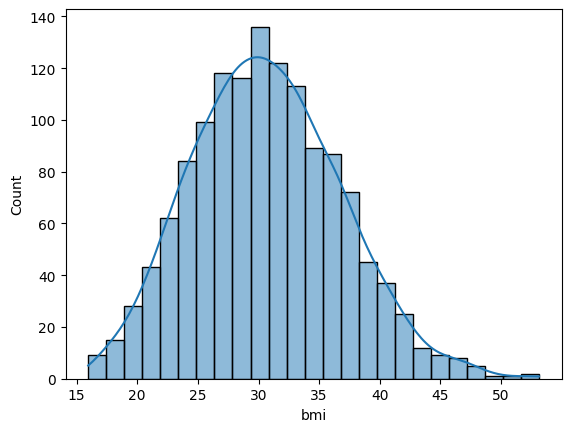

In [13]:
sns.histplot(data = df,x = 'bmi',kde = True)
plt.show()

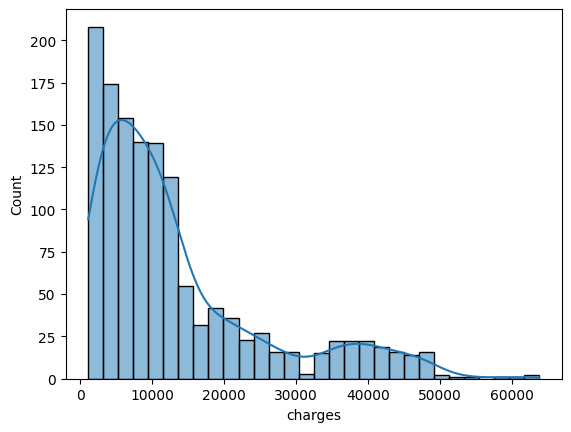

In [14]:
sns.histplot(data = df,x = 'charges',kde = True)
plt.show()

In [15]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df.drop("Id",inplace = True , axis = 1)

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
df["sex"] = df["sex"].map({"male" : 0, "female": 1})
df["smoker"] = df["smoker"].map({"no" : 0, "yes": 1})

In [19]:
df.sex.value_counts()

sex
0    676
1    662
Name: count, dtype: int64

In [20]:
df.smoker.value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 73.3 KB


In [22]:
#one hot encoding -> region

In [23]:
X = df.drop("charges",axis = 1)
y = df["charges"]

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [26]:

categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=
                                [
                                    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
                                ], remainder= "passthrough"
                                )

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [27]:
from lightgbm import LGBMRegressor

In [28]:

model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390


/home/bayazit/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [29]:

from sklearn.metrics import r2_score, mean_squared_error

In [30]:

print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8636669836215215
18458085.613847945


from lightgbm import LGBMRegressor

# LightGBM Regressor Parametrləri Cheat Sheet
lgbm_reg = LGBMRegressor(
    # =================================================================
    # 1. ÜMUMİ VƏ ÖYRƏNMƏ PARAMETRLƏRİ (GENERAL & LEARNING)
    # =================================================================

    # boosting_type (Default: 'gbdt')
    # İstfadə ediləcək alqoritm. 
    # 'gbdt' (Gradient Boosting Decision Tree) ən yaxşı və stabil seçimdir.
    boosting_type='gbdt',

    # objective (Default: 'regression')
    # Hədəf funksiyası (ƏN BÖYÜK FƏRQ BURADADIR!)
    # - 'regression' (və ya 'l2'): Standart Mean Squared Error (MSE). Əksər hallarda istifadə olunur.
    # - 'regression_l1' (və ya 'mae'): Mean Absolute Error. Datanda çoxlu "outlier" (anormal kənar dəyərlər) varsa bunu seç.
    # - 'huber': Outlier-lərə qarşı L1 və L2-nin qarışığı olan çox dözümlü bir metoddur.
    # - 'mape': Mean Absolute Percentage Error. Xətaları faizlə optimallaşdırmaq istədikdə (məs: biznes hesabatları üçün).
    objective='regression',

    # learning_rate (Default: 0.1)
    # Öyrənmə sürəti. 
    # Dəqiqlik üçün adətən 0.01 - 0.05 arası seçilir. Bunu azaltdıqda n_estimators-u qaldırmalısan.
    learning_rate=0.05,

    # n_estimators (Default: 100)
    # Qurulacaq ağacların (boosting mərhələlərinin) sayı. 
    n_estimators=500,

    # =================================================================
    # 2. AĞACIN STRUKTURU (TREE STRUCTURE) - OVERFITTING NƏZARƏTİ
    # =================================================================

    # num_leaves (Default: 31)
    # Bir ağacdakı maksimum yarpaq sayı. Modelin mürəkkəbliyini təyin edir.
    # Yenə də qayda eynidir: < 2^(max_depth) olmalıdır.
    num_leaves=31,

    # max_depth (Default: -1)
    # Ağacın maksimum dərinliyi. -1 limitsiz deməkdir.
    # Reqressiyada datanı əzbərləməmək (overfitting) üçün 3-7 arası tutmaq məsləhətdir.
    max_depth=5,

    # min_child_samples (Default: 20)
    # Bir yarpaqda (yekun təxmin qutusunda) olmalı ən az data sayı.
    # Outlier-lərin xüsusi yarpaqlar yaradıb modeli pozmasının qarşısını alır.
    # Datan böyükdürsə 50, 100 kimi rəqəmlər yoxla.
    min_child_samples=30,

    # min_split_gain (Default: 0.0)
    # Bir düyünün (node) bölünməsi üçün tələb olunan minimum itki azalması.
    min_split_gain=0.01,

    # =================================================================
    # 3. TƏSADÜFİLİK VƏ NÜMUNƏLƏMƏ (SAMPLING & RANDOMNESS)
    # =================================================================

    # subsample (Default: 1.0)
    # Hər iterasiyada sətirlərin neçə faizinin təsadüfi seçiləcəyi (0.8 = 80%).
    # Modelin ümumiləşdirmə (generalization) qabiliyyətini artırır.
    subsample=0.8,

    # subsample_freq (Default: 0)
    # Sətir nümunələməsinin (subsample) neçə ağacdan bir ediləcəyi. 
    # 'subsample' istifadə edirsənsə bunu mütləq 1 (və ya başqa müsbət rəqəm) etməlisən!
    subsample_freq=1,

    # colsample_bytree (Default: 1.0)
    # Hər ağac qurularkən sütunların (feature-ların) neçə faizinin təsadüfi seçiləcəyi.
    colsample_bytree=0.8,

    # =================================================================
    # 4. REQULYARİZASİYA (REGULARIZATION)
    # =================================================================

    # reg_alpha (Default: 0.0)
    # L1 Requlyarizasiyası (Lasso). Sütun sayı (feature) çoxdursa, lazımsızları sıfırlayır.
    reg_alpha=0.1,

    # reg_lambda (Default: 0.0)
    # L2 Requlyarizasiyası (Ridge). Çəkiləri (weights) kiçildir, əzbərləm

In [31]:
#hyperparametr tuning

In [32]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [33]:
from sklearn.model_selection import RandomizedSearchCV

In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs = -1
)

In [36]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [37]:

random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [38]:
y_pred = random_search.predict(X_test)

In [39]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8775521864086795
16446549.93278381


In [40]:
# let's try with a transformation on the dependent feature

In [42]:
from scipy.stats import boxcox
y_train_transformed, lambda_y = boxcox(y_train)

In [43]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [44]:

y_pred_transformed = model.predict(X_test)

In [45]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [46]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [47]:
print(r2_score(y_pred_original, y_test))
print(mean_squared_error(y_pred_original, y_test))

0.8895535054323228
15470028.378876308
